# NLP Assignment 3 — Transformers + RAG
**Roll Number:** I232641  
**Course:** CS-4063 Natural Language Processing  

**Execution Instructions:**
1. Upload your 3 dataset `.json`/`.jsonl` files to `/MyDrive/NLP/` in Google Drive
2. Runtime → Change Runtime Type → **GPU** (T4)
3. Runtime → Run All
4. Update `FILE_PATHS` in the Dataset cell with your actual filenames if different

## Setup & Imports

In [1]:
# Install required packages
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q matplotlib scikit-learn tqdm

In [2]:
# Core imports for the entire pipeline
import os, json, re, math, random, time, pickle
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, accuracy_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

Using device: cuda


## Dataset Loading

In [3]:
# Mount Google Drive to access dataset files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Load 3 Amazon Review category files; update filenames below to match your Drive/NLP folder
DRIVE_NLP = '/content/drive/MyDrive/NLP'

# List available files so user can verify
print('Files in Drive/NLP:')
for f in sorted(os.listdir(DRIVE_NLP)):
    print(' ', f)

# ---- UPDATE THESE THREE FILENAMES TO MATCH YOUR FILES ----
FILE_PATHS = [
    os.path.join(DRIVE_NLP, 'Electronics_5.json'),       # Category 1
    os.path.join(DRIVE_NLP, 'Sports_and_Outdoors_5.json'), # Category 2
    os.path.join(DRIVE_NLP, 'Home_and_Kitchen_5.json'),   # Category 3
]
SAMPLES_PER_CAT = 12000   # 10k-15k per category → ~36k total

def load_amazon_file(path, max_samples):
    records = []
    with open(path, 'r') as f:
        for line in f:
            try:
                obj = json.loads(line.strip())
                text = obj.get('reviewText', '') or obj.get('summary', '')
                rating = obj.get('overall', None)
                if text and rating and isinstance(rating, (int, float)):
                    records.append({'text': str(text), 'rating': int(rating)})
                    if len(records) >= max_samples:
                        break
            except:
                continue
    return records

all_records = []
for fp in FILE_PATHS:
    cat_name = os.path.basename(fp).split('_5')[0].split('.json')[0]
    recs = load_amazon_file(fp, SAMPLES_PER_CAT)
    for r in recs: r['category'] = cat_name
    all_records.extend(recs)
    print(f'Loaded {len(recs):,} reviews from {cat_name}')

random.shuffle(all_records)
print(f'\nTotal records: {len(all_records):,}')

Files in Drive/NLP:
  Beauty_5.json
  Cell_Phones_and_Accessories_5.json
  Electronics_5.json
  Home_and_Kitchen_5.json
  Sports_and_Outdoors_5.json
  models
  results
Loaded 12,000 reviews from Electronics
Loaded 12,000 reviews from Sports_and_Outdoors
Loaded 12,000 reviews from Home_and_Kitchen

Total records: 36,000


## Preprocessing

In [5]:
# Text cleaning, tokenization, vocabulary building, and train/val/test split
MAX_LEN = 128
MIN_FREQ = 3
PAD_TOKEN, UNK_TOKEN, BOS_TOKEN, EOS_TOKEN = '<PAD>', '<UNK>', '<BOS>', '<EOS>'

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)          # strip HTML
    text = re.sub(r'[^a-z0-9\s\'.,!?]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def simple_tokenize(text):
    return text.split()

# Map ratings to sentiment labels: 1-2→0(Neg), 3→1(Neu), 4-5→2(Pos)
def rating_to_sentiment(r):
    if r <= 2: return 0
    if r == 3: return 1
    return 2

# Derived task: review length bucket (short<30, medium 30-80, long>80 tokens)
def length_bucket(tokens):
    n = len(tokens)
    if n < 30: return 0
    if n <= 80: return 1
    return 2

# Preprocess all records
for r in all_records:
    r['tokens'] = simple_tokenize(clean_text(r['text']))
    r['sentiment'] = rating_to_sentiment(r['rating'])
    r['len_label'] = length_bucket(r['tokens'])

# Train/val/test split 70/15/15
n = len(all_records)
n_train = int(0.70 * n); n_val = int(0.15 * n)
train_data = all_records[:n_train]
val_data   = all_records[n_train:n_train+n_val]
test_data  = all_records[n_train+n_val:]
print(f'Train: {len(train_data):,}  Val: {len(val_data):,}  Test: {len(test_data):,}')

# Build vocabulary from training data only
counter = Counter()
for r in train_data: counter.update(r['tokens'])
vocab_tokens = [t for t, c in counter.items() if c >= MIN_FREQ]
specials = [PAD_TOKEN, UNK_TOKEN, BOS_TOKEN, EOS_TOKEN]
vocab = specials + vocab_tokens
w2i = {w: i for i, w in enumerate(vocab)}
i2w = {i: w for w, i in w2i.items()}
PAD_IDX, UNK_IDX, BOS_IDX, EOS_IDX = 0, 1, 2, 3
VOCAB_SIZE = len(vocab)
print(f'Vocabulary size: {VOCAB_SIZE:,}')

def encode(tokens, max_len=MAX_LEN):
    ids = [w2i.get(t, UNK_IDX) for t in tokens[:max_len]]
    ids += [PAD_IDX] * (max_len - len(ids))
    return ids

Train: 25,200  Val: 5,400  Test: 5,400
Vocabulary size: 24,991


# Part A — Encoder Model for Understanding

In [6]:
# Scaled dot-product attention, multi-head attention, and encoder block built entirely from scratch

class ScaledDotProductAttention(nn.Module):
    def __init__(self, d_k, dropout=0.1):
        super().__init__()
        self.scale = math.sqrt(d_k)
        self.dropout = nn.Dropout(dropout)

    def forward(self, Q, K, V, mask=None):
        scores = torch.matmul(Q, K.transpose(-2, -1)) / self.scale
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        attn = self.dropout(F.softmax(scores, dim=-1))
        return torch.matmul(attn, V), attn


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_k = d_model // num_heads
        self.num_heads = num_heads
        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        self.W_O = nn.Linear(d_model, d_model)
        self.attention = ScaledDotProductAttention(self.d_k, dropout)

    def forward(self, Q, K, V, mask=None):
        B = Q.size(0)
        Q = self.W_Q(Q).view(B, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_K(K).view(B, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_V(V).view(B, -1, self.num_heads, self.d_k).transpose(1, 2)
        # mask is already (B,1,1,T) from make_pad_mask or (B,1,T,T) for causal — no extra unsqueeze needed
        out, _ = self.attention(Q, K, V, mask)
        out = out.transpose(1, 2).contiguous().view(B, -1, self.num_heads * self.d_k)
        return self.W_O(out)


class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )
    def forward(self, x): return self.net(x)


class EncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ff   = FeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop1 = nn.Dropout(dropout)
        self.drop2 = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        x = self.norm1(x + self.drop1(self.attn(x, x, x, mask)))
        x = self.norm2(x + self.drop2(self.ff(x)))
        return x


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class EncoderModel(nn.Module):
    def __init__(self, vocab_size, d_model=256, num_heads=8, d_ff=512,
                 num_layers=4, max_len=MAX_LEN, dropout=0.1,
                 num_sentiment=3, num_len_class=3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_enc   = PositionalEncoding(d_model, max_len, dropout)
        self.layers    = nn.ModuleList([EncoderBlock(d_model, num_heads, d_ff, dropout)
                                        for _ in range(num_layers)])
        self.sentiment_head = nn.Linear(d_model, num_sentiment)
        self.len_head       = nn.Linear(d_model, num_len_class)

    def forward(self, x, mask=None):
        x = self.pos_enc(self.embedding(x))
        for layer in self.layers:
            x = layer(x, mask)
        cls_vec = x[:, 0, :]                         # CLS token representation
        return self.sentiment_head(cls_vec), self.len_head(cls_vec), cls_vec

print('Encoder architecture defined.')

Encoder architecture defined.


In [7]:
# PyTorch Dataset and DataLoader for the encoder training pipeline
class ReviewDataset(Dataset):
    def __init__(self, records):
        self.records = records

    def __len__(self): return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]
        ids = encode(r['tokens'])
        return (
            torch.tensor(ids, dtype=torch.long),
            torch.tensor(r['sentiment'], dtype=torch.long),
            torch.tensor(r['len_label'], dtype=torch.long)
        )

BATCH_SIZE = 64
train_ds = ReviewDataset(train_data)
val_ds   = ReviewDataset(val_data)
test_ds  = ReviewDataset(test_data)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f'Batches — Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}')

Batches — Train: 394, Val: 85, Test: 85


In [8]:
# Train the encoder with combined cross-entropy loss for both tasks and print epoch progress
ENC_EPOCHS  = 10
LR          = 3e-4
LAMBDA_SENT = 1.0
LAMBDA_LEN  = 0.5

encoder = EncoderModel(VOCAB_SIZE).to(device)
optimizer = torch.optim.Adam(encoder.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=ENC_EPOCHS)
ce_loss   = nn.CrossEntropyLoss()

def make_pad_mask(x):
    return (x != PAD_IDX).unsqueeze(1).unsqueeze(2)  # (B,1,1,T)

enc_train_losses, enc_val_losses = [], []
enc_train_accs,   enc_val_accs   = [], []

for epoch in range(1, ENC_EPOCHS + 1):
    encoder.train()
    total_loss, correct, total = 0, 0, 0
    for ids, sent_lbl, len_lbl in train_loader:
        ids, sent_lbl, len_lbl = ids.to(device), sent_lbl.to(device), len_lbl.to(device)
        mask = make_pad_mask(ids)
        sent_logits, len_logits, _ = encoder(ids, mask)
        loss = LAMBDA_SENT * ce_loss(sent_logits, sent_lbl) + LAMBDA_LEN * ce_loss(len_logits, len_lbl)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item() * ids.size(0)
        correct += (sent_logits.argmax(-1) == sent_lbl).sum().item()
        total   += ids.size(0)
    scheduler.step()
    t_loss = total_loss / total; t_acc = correct / total
    enc_train_losses.append(t_loss); enc_train_accs.append(t_acc)

    encoder.eval()
    v_loss, v_correct, v_total = 0, 0, 0
    with torch.no_grad():
        for ids, sent_lbl, len_lbl in val_loader:
            ids, sent_lbl, len_lbl = ids.to(device), sent_lbl.to(device), len_lbl.to(device)
            mask = make_pad_mask(ids)
            sl, ll, _ = encoder(ids, mask)
            v_loss += (LAMBDA_SENT * ce_loss(sl, sent_lbl) + LAMBDA_LEN * ce_loss(ll, len_lbl)).item() * ids.size(0)
            v_correct += (sl.argmax(-1) == sent_lbl).sum().item()
            v_total   += ids.size(0)
    v_loss /= v_total; v_acc = v_correct / v_total
    enc_val_losses.append(v_loss); enc_val_accs.append(v_acc)

    print(f'Epoch [{epoch}/{ENC_EPOCHS}]  TrainLoss: {t_loss:.4f}  TrainAcc: {t_acc:.4f}  ValLoss: {v_loss:.4f}  ValAcc: {v_acc:.4f}')

os.makedirs('models', exist_ok=True)
torch.save(encoder.state_dict(), 'models/encoder.pt')
print('Encoder saved.')

Epoch [1/10]  TrainLoss: 0.5582  TrainAcc: 0.8492  ValLoss: 0.4933  ValAcc: 0.8526
Epoch [2/10]  TrainLoss: 0.4813  TrainAcc: 0.8510  ValLoss: 0.4540  ValAcc: 0.8539
Epoch [3/10]  TrainLoss: 0.4481  TrainAcc: 0.8521  ValLoss: 0.4491  ValAcc: 0.8544
Epoch [4/10]  TrainLoss: 0.4138  TrainAcc: 0.8593  ValLoss: 0.4463  ValAcc: 0.8580
Epoch [5/10]  TrainLoss: 0.3790  TrainAcc: 0.8674  ValLoss: 0.4233  ValAcc: 0.8526
Epoch [6/10]  TrainLoss: 0.3428  TrainAcc: 0.8769  ValLoss: 0.4279  ValAcc: 0.8556
Epoch [7/10]  TrainLoss: 0.3049  TrainAcc: 0.8880  ValLoss: 0.4413  ValAcc: 0.8544
Epoch [8/10]  TrainLoss: 0.2673  TrainAcc: 0.9009  ValLoss: 0.4670  ValAcc: 0.8526
Epoch [9/10]  TrainLoss: 0.2378  TrainAcc: 0.9133  ValLoss: 0.4830  ValAcc: 0.8498
Epoch [10/10]  TrainLoss: 0.2216  TrainAcc: 0.9200  ValLoss: 0.4977  ValAcc: 0.8504
Encoder saved.


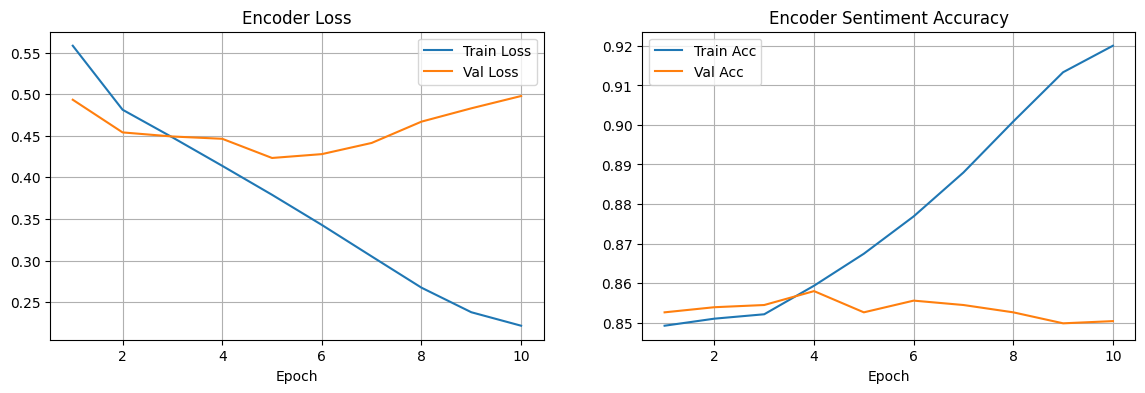

In [10]:
# Plot encoder learning curves for loss and sentiment accuracy
epochs = range(1, ENC_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(epochs, enc_train_losses, label='Train Loss')
axes[0].plot(epochs, enc_val_losses,   label='Val Loss')
axes[0].set_title('Encoder Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True)
axes[1].plot(epochs, enc_train_accs, label='Train Acc')
axes[1].plot(epochs, enc_val_accs,   label='Val Acc')
axes[1].set_title('Encoder Sentiment Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True)
#plt.tight_layout(); plt.savefig('results/encoder_curves.png', dpi=150); plt.show()

In [11]:
# Evaluate encoder on test set and report metrics for both sentiment and length tasks
os.makedirs('results', exist_ok=True)
encoder.eval()
all_sent_true, all_sent_pred = [], []
all_len_true,  all_len_pred  = [], []

with torch.no_grad():
    for ids, sent_lbl, len_lbl in test_loader:
        ids = ids.to(device)
        mask = make_pad_mask(ids)
        sl, ll, _ = encoder(ids, mask)
        all_sent_pred.extend(sl.argmax(-1).cpu().tolist())
        all_sent_true.extend(sent_lbl.tolist())
        all_len_pred.extend(ll.argmax(-1).cpu().tolist())
        all_len_true.extend(len_lbl.tolist())

print('=== Sentiment Classification (Task 1) ===')
print(classification_report(all_sent_true, all_sent_pred,
      target_names=['Negative','Neutral','Positive']))
print('=== Length Bucket Classification (Task 2) ===')
print(classification_report(all_len_true, all_len_pred,
      target_names=['Short','Medium','Long']))

=== Sentiment Classification (Task 1) ===
              precision    recall  f1-score   support

    Negative       0.44      0.29      0.35       426
     Neutral       0.23      0.12      0.16       369
    Positive       0.89      0.96      0.92      4605

    accuracy                           0.85      5400
   macro avg       0.52      0.45      0.48      5400
weighted avg       0.81      0.85      0.83      5400

=== Length Bucket Classification (Task 2) ===
              precision    recall  f1-score   support

       Short       1.00      0.99      0.99      1143
      Medium       0.99      1.00      1.00      2240
        Long       1.00      1.00      1.00      2017

    accuracy                           1.00      5400
   macro avg       1.00      1.00      1.00      5400
weighted avg       1.00      1.00      1.00      5400



In [12]:
# Extract and save encoder embeddings for the full training set to use in retrieval
encoder.eval()
train_embeds = []
train_loader_noshuffle = DataLoader(train_ds, batch_size=128, shuffle=False, num_workers=2)

with torch.no_grad():
    for batch_idx, (ids, _, _) in enumerate(train_loader_noshuffle):
        ids = ids.to(device)
        mask = make_pad_mask(ids)
        _, _, cls_vec = encoder(ids, mask)
        train_embeds.append(cls_vec.cpu())
        if (batch_idx + 1) % 50 == 0:
            print(f'Embedded batch {batch_idx+1}/{len(train_loader_noshuffle)}')

train_embeds = torch.cat(train_embeds, dim=0)   # (N_train, d_model)
train_embeds_norm = F.normalize(train_embeds, dim=-1)

with open('results/train_embeddings.pkl', 'wb') as f:
    pickle.dump({'embeds': train_embeds_norm, 'data': train_data}, f)
print(f'Saved training embeddings: {train_embeds_norm.shape}')

Embedded batch 50/197
Embedded batch 100/197
Embedded batch 150/197
Saved training embeddings: torch.Size([25200, 256])


# Part B — Retrieval Module

In [13]:
# Retrieval module: cosine similarity search over stored training embeddings
with open('results/train_embeddings.pkl', 'rb') as f:
    store = pickle.load(f)
stored_embeds = store['embeds']   # (N_train, d_model), L2-normalised
stored_data   = store['data']

TOP_K = 3   # configurable; 3 balances relevance vs. input length for the decoder

def retrieve(query_embed, k=TOP_K):
    """Return top-k training records by cosine similarity."""
    q = F.normalize(query_embed.unsqueeze(0), dim=-1)   # (1, d)
    sims = (stored_embeds @ q.T).squeeze(-1)             # (N,)
    top_k_idx = sims.topk(k).indices.tolist()
    return [(stored_data[i], sims[i].item()) for i in top_k_idx]

print(f'Retrieval module ready. k={TOP_K}, index size={len(stored_data):,}')

Retrieval module ready. k=3, index size=25,200


In [14]:
# Evaluate retrieval quality with 5 sample queries from the test set
encoder.eval()
SENT_NAMES = ['Negative', 'Neutral', 'Positive']

# Sample 5 test reviews for qualitative analysis
sample_tests = random.sample(test_data, 5)

for i, record in enumerate(sample_tests):
    ids = torch.tensor(encode(record['tokens']), dtype=torch.long).unsqueeze(0).to(device)
    with torch.no_grad():
        mask = make_pad_mask(ids)
        _, _, q_emb = encoder(ids, mask)
    retrieved = retrieve(q_emb.cpu().squeeze(0))

    print(f'\n--- Query {i+1} ---')
    print(f'Text   : {record["text"][:120]}...')
    print(f'Rating : {record["rating"]}  Sentiment: {SENT_NAMES[record["sentiment"]]}')
    for j, (ret, sim) in enumerate(retrieved):
        print(f'  Retrieved {j+1} (sim={sim:.3f}, rating={ret["rating"]}): {ret["text"][:80]}...')


--- Query 1 ---
Text   : If you need to carry two speedloaders securely, the HKS Plain Double Speedloader Case does it extremely well.  It is mad...
Rating : 5  Sentiment: Positive
  Retrieved 1 (sim=0.978, rating=5): If you've been doing you're homework on all of the PDA's out there now then you ...
  Retrieved 2 (sim=0.974, rating=5): If you write a lot while on the road, because of your job or simply because you ...
  Retrieved 3 (sim=0.974, rating=5): If you are a serious close-up or macro photographer, sooner or later (but probab...

--- Query 2 ---
Text   : I shopped around for digital cameras for a month before deciding on the Fuji 1300. Its low price makes it a fantastic fi...
Rating : 4  Sentiment: Positive
  Retrieved 1 (sim=0.905, rating=5): I already own one of these as an EDC knife and that is why I have purchased more...
  Retrieved 2 (sim=0.899, rating=5): I have been looking for some Silhouette targets for a while now, but I believe t...
  Retrieved 3 (sim=0.897, ratin

# Part C — Decoder Model for Explanation Generation

In [15]:
# Decoder-only Transformer with causal (masked) self-attention built from scratch

class DecoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ff        = FeedForward(d_model, d_ff, dropout)
        self.norm1     = nn.LayerNorm(d_model)
        self.norm2     = nn.LayerNorm(d_model)
        self.drop1     = nn.Dropout(dropout)
        self.drop2     = nn.Dropout(dropout)

    def forward(self, x, causal_mask):
        x = self.norm1(x + self.drop1(self.self_attn(x, x, x, causal_mask)))
        x = self.norm2(x + self.drop2(self.ff(x)))
        return x


class DecoderModel(nn.Module):
    def __init__(self, vocab_size, d_model=256, num_heads=8, d_ff=512,
                 num_layers=4, max_len=256, dropout=0.1):
        super().__init__()
        self.d_model    = d_model
        self.embedding  = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.pos_enc    = PositionalEncoding(d_model, max_len, dropout)
        self.layers     = nn.ModuleList([DecoderBlock(d_model, num_heads, d_ff, dropout)
                                         for _ in range(num_layers)])
        self.proj       = nn.Linear(d_model, vocab_size)

    def make_causal_mask(self, T):
        # Lower-triangular (1,1,T,T) mask prevents attending to future tokens; broadcasts over batch and heads
        return torch.tril(torch.ones(1, 1, T, T))

    def forward(self, x):
        T = x.size(1)
        mask = self.make_causal_mask(T).to(x.device)
        x = self.pos_enc(self.embedding(x))
        for layer in self.layers:
            x = layer(x, mask)
        return self.proj(x)   # (B, T, vocab_size)

print('Decoder architecture defined.')

Decoder architecture defined.


In [16]:
# Build decoder training sequences by combining review + sentiment + length + retrieved context
DEC_MAX_LEN = 200
SENT_MAP = {0: 'negative', 1: 'neutral', 2: 'positive'}
LEN_MAP  = {0: 'short', 1: 'medium', 2: 'long'}

def build_decoder_input(record, retrieved_records):
    """Template: [BOS] review: <text> sentiment: <lbl> length: <lbl> examples: <ex1> ... explanation: [EOS]"""
    review_text = ' '.join(record['tokens'][:50])
    sent_str    = SENT_MAP[record['sentiment']]
    len_str     = LEN_MAP[record['len_label']]
    ctx_parts   = [' '.join(r['tokens'][:20]) for r, _ in retrieved_records]
    ctx_str     = ' | '.join(ctx_parts)

    # Reference explanation template (silver label)
    explanation = f'this review is {sent_str} because the reviewer expresses {sent_str} experience with a {len_str} review'

    full = f'review: {review_text} sentiment: {sent_str} length: {len_str} context: {ctx_str} explanation: {explanation}'
    tokens = simple_tokenize(clean_text(full))
    ids = [BOS_IDX] + [w2i.get(t, UNK_IDX) for t in tokens] + [EOS_IDX]
    ids = ids[:DEC_MAX_LEN] + [PAD_IDX] * max(0, DEC_MAX_LEN - len(ids))
    return ids


class DecoderDataset(Dataset):
    def __init__(self, records, embed_tensor, stored_data, k=TOP_K):
        self.records      = records
        self.embed_tensor = embed_tensor   # pre-computed embeddings aligned with records
        self.stored_embeds = stored_embeds
        self.stored_data   = stored_data
        self.k = k

    def __len__(self): return len(self.records)

    def __getitem__(self, idx):
        record = self.records[idx]
        q_emb  = self.embed_tensor[idx]         # pre-computed, no GPU needed here
        retrieved = retrieve(q_emb, self.k)
        ids = build_decoder_input(record, retrieved)
        ids_t = torch.tensor(ids, dtype=torch.long)
        return ids_t[:-1], ids_t[1:]            # input, target (shifted by 1)

# Pre-compute embeddings for train/val/test splits for decoder dataset
def compute_split_embeds(split_ds):
    loader = DataLoader(split_ds, batch_size=256, shuffle=False, num_workers=2)
    out = []
    encoder.eval()
    with torch.no_grad():
        for ids, _, _ in loader:
            mask = make_pad_mask(ids.to(device))
            _, _, v = encoder(ids.to(device), mask)
            out.append(F.normalize(v, dim=-1).cpu())
    return torch.cat(out, 0)

print('Computing embeddings for decoder datasets...')
train_emb_all = compute_split_embeds(train_ds)
val_emb_all   = compute_split_embeds(val_ds)
test_emb_all  = compute_split_embeds(test_ds)
print('Done.')

dec_train_ds = DecoderDataset(train_data, train_emb_all, stored_data)
dec_val_ds   = DecoderDataset(val_data,   val_emb_all,   stored_data)
dec_test_ds  = DecoderDataset(test_data,  test_emb_all,  stored_data)
dec_train_loader = DataLoader(dec_train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
dec_val_loader   = DataLoader(dec_val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
dec_test_loader  = DataLoader(dec_test_ds,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
print(f'Decoder loaders — Train: {len(dec_train_loader)}, Val: {len(dec_val_loader)}, Test: {len(dec_test_loader)}')

Computing embeddings for decoder datasets...
Done.
Decoder loaders — Train: 788, Val: 169, Test: 169


In [17]:
# Train the decoder with language modelling objective and print per-epoch loss and perplexity
DEC_EPOCHS = 10
DEC_LR     = 3e-4

decoder = DecoderModel(VOCAB_SIZE).to(device)
dec_optimizer = torch.optim.Adam(decoder.parameters(), lr=DEC_LR, weight_decay=1e-5)
dec_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(dec_optimizer, T_max=DEC_EPOCHS)
lm_loss = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

dec_train_losses, dec_val_losses = [], []

for epoch in range(1, DEC_EPOCHS + 1):
    decoder.train()
    t_loss, t_count = 0.0, 0
    for inp, tgt in dec_train_loader:
        inp, tgt = inp.to(device), tgt.to(device)
        logits = decoder(inp)                              # (B, T-1, V)
        loss = lm_loss(logits.reshape(-1, VOCAB_SIZE), tgt.reshape(-1))
        dec_optimizer.zero_grad(); loss.backward(); dec_optimizer.step()
        t_loss  += loss.item() * inp.size(0)
        t_count += inp.size(0)
    dec_scheduler.step()
    t_loss /= t_count

    decoder.eval()
    v_loss, v_count = 0.0, 0
    with torch.no_grad():
        for inp, tgt in dec_val_loader:
            inp, tgt = inp.to(device), tgt.to(device)
            logits = decoder(inp)
            v_loss  += lm_loss(logits.reshape(-1, VOCAB_SIZE), tgt.reshape(-1)).item() * inp.size(0)
            v_count += inp.size(0)
    v_loss /= v_count
    dec_train_losses.append(t_loss); dec_val_losses.append(v_loss)

    print(f'Epoch [{epoch}/{DEC_EPOCHS}]  TrainLoss: {t_loss:.4f}  TrainPPL: {math.exp(t_loss):.2f}  '
          f'ValLoss: {v_loss:.4f}  ValPPL: {math.exp(v_loss):.2f}')

torch.save(decoder.state_dict(), 'models/decoder.pt')
print('Decoder saved.')

Epoch [1/10]  TrainLoss: 5.0711  TrainPPL: 159.34  ValLoss: 4.4994  ValPPL: 89.97
Epoch [2/10]  TrainLoss: 4.2529  TrainPPL: 70.31  ValLoss: 4.3084  ValPPL: 74.32
Epoch [3/10]  TrainLoss: 3.8413  TrainPPL: 46.58  ValLoss: 4.2801  ValPPL: 72.25
Epoch [4/10]  TrainLoss: 3.5382  TrainPPL: 34.41  ValLoss: 4.2712  ValPPL: 71.61
Epoch [5/10]  TrainLoss: 3.3247  TrainPPL: 27.79  ValLoss: 4.2639  ValPPL: 71.08
Epoch [6/10]  TrainLoss: 3.1767  TrainPPL: 23.97  ValLoss: 4.2499  ValPPL: 70.10
Epoch [7/10]  TrainLoss: 3.0766  TrainPPL: 21.68  ValLoss: 4.2609  ValPPL: 70.88
Epoch [8/10]  TrainLoss: 3.0109  TrainPPL: 20.31  ValLoss: 4.2588  ValPPL: 70.72
Epoch [9/10]  TrainLoss: 2.9730  TrainPPL: 19.55  ValLoss: 4.2604  ValPPL: 70.84
Epoch [10/10]  TrainLoss: 2.9542  TrainPPL: 19.19  ValLoss: 4.2607  ValPPL: 70.86
Decoder saved.
